# E-commerce Product Recommendation System

A collaborative filtering-based recommendation engine using the UCI Online Retail dataset to suggest personalized products to customers.

## Table of Contents
1. Problem Statement  
2. Dataset Overview  
3. Data Loading & Cleaning  
4. Exploratory Data Analysis  
5. Feature Engineering  
6. Model Building & Evaluation  
7. Recommendation System  
8. Interactive Demo  
9. Conclusion


In [ ]:
!pip install scikit-surprise plotly gradio -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, SVD, KNNBasic, accuracy
from surprise.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

print("Libraries installed successfully!")

Libraries installed successfully!


# 1. Problem Statement

E-commerce platforms contain thousands of products, making it difficult for users to discover relevant items.

Recommendation systems help improve user experience by suggesting products based on previous interactions and purchase history.

The goal of this project is to build a recommendation engine capable of generating personalized product suggestions for individual customers.

## 2. Dataset Overview

This project uses the **Online Retail Dataset** from UCI Machine Learning Repository containing real transactional data from a UK-based online retailer.

### Important Features

| Feature | Description |
|----------|------------|
| InvoiceNo | Transaction ID |
| StockCode | Product ID |
| Description | Product Name |
| Quantity | Number of Units Purchased |
| InvoiceDate | Date of Purchase |
| CustomerID | Unique Customer Identifier |
| Country | Customer Country |

### Dataset Characteristics

- Real-world retail transactions
- Multiple customers and products
- Suitable for collaborative filtering
- Implicit feedback dataset (purchase history)

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload "Online Retail.xlsx"

Saving Online Retail.xlsx to Online Retail (3).xlsx


# 3. Data Loading & Cleaning

The dataset was loaded from an Excel file and cleaned to ensure data quality before building the recommendation system.

### Cleaning Steps Performed

- Removed records with missing Customer IDs.
- Converted CustomerID to integer format.
- Removed transactions with non-positive quantities.
- Removed transactions with non-positive unit prices.
- Converted InvoiceDate to datetime format.
- Extracted Month information from InvoiceDate for trend analysis.

These preprocessing steps ensure that only valid purchase transactions are used for recommendation modeling.

In [ ]:
df = pd.read_excel('Online Retail.xlsx')

print("Original Shape:", df.shape)
print(df.head())

df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

print("Cleaned Shape:", df.shape)

Original Shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Cleaned Shape: (397884, 9)


# 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand customer purchasing patterns, product popularity, and dataset characteristics before building the recommendation model.

### Analyses Performed

#### 1. Product and Customer Analysis
- Identified the most purchased products.
- Identified the customers with the highest total purchase quantities.

#### 2. Monthly Transaction Trends
Transaction counts were analyzed across different months to observe purchasing trends over time.

### Purpose

These analyses help validate the suitability of collaborative filtering techniques and provide insights into customer purchasing behavior.

Top 10 Most Purchased Products:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

Most Active Customers:
CustomerID
14646    196915
16446     80997
14911     80265
12415     77374
12346     74215
17450     69993
17511     64549
18102     64124
13694     63312
14298     58343
Name: Quantity, dtype: int64


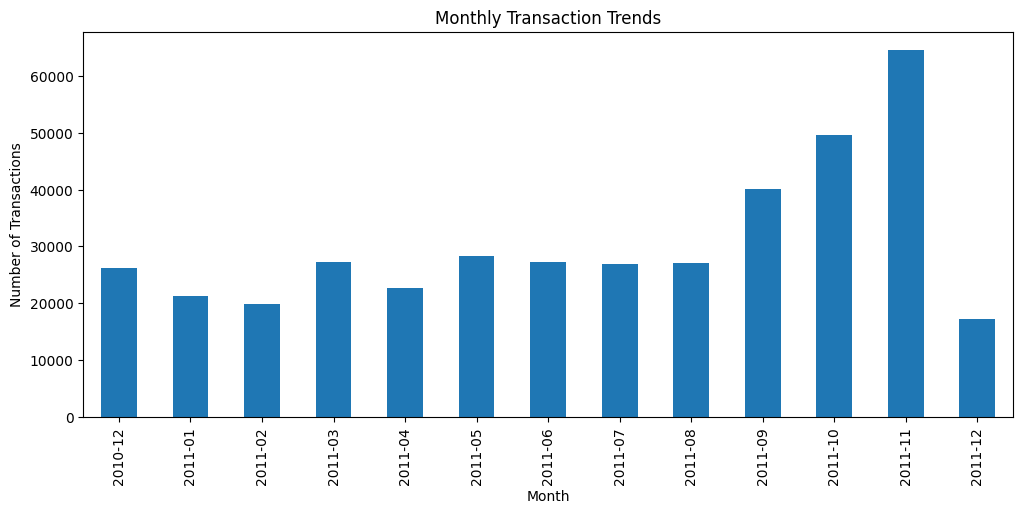

In [ ]:
# 1. Top Products
print("Top 10 Most Purchased Products:")
print(df.groupby('Description')['Quantity'].sum().nlargest(10))

# 2. Most Active Customers
print("\nMost Active Customers:")
print(df.groupby('CustomerID')['Quantity'].sum().nlargest(10))

# 3. Monthly Trends
monthly = df.groupby('Month').size()
monthly.plot(kind='bar', figsize=(12,5))
plt.title('Monthly Transaction Trends')
plt.ylabel('Number of Transactions')
plt.show()

# 5. Feature Engineering

Customer-product interactions were created by aggregating purchase quantities for each CustomerID and StockCode pair.

Purchase quantity was treated as an implicit rating and transformed using a logarithmic function (`log1p`) to reduce the influence of extremely large purchase quantities while preserving differences between customer preferences.

The final interaction dataset includes:
- CustomerID
- StockCode
- Description
- Rating
- Latest Purchase Date

#### Rating Distribution
Purchase quantities were converted into ratings and their distribution was visualized to understand customer-product interaction patterns.

#### Sparsity Analysis
The sparsity of the user-item interaction matrix was calculated.

A highly sparse matrix indicates that customers interact with only a small fraction of the available products, which is a common characteristic of recommendation system datasets.

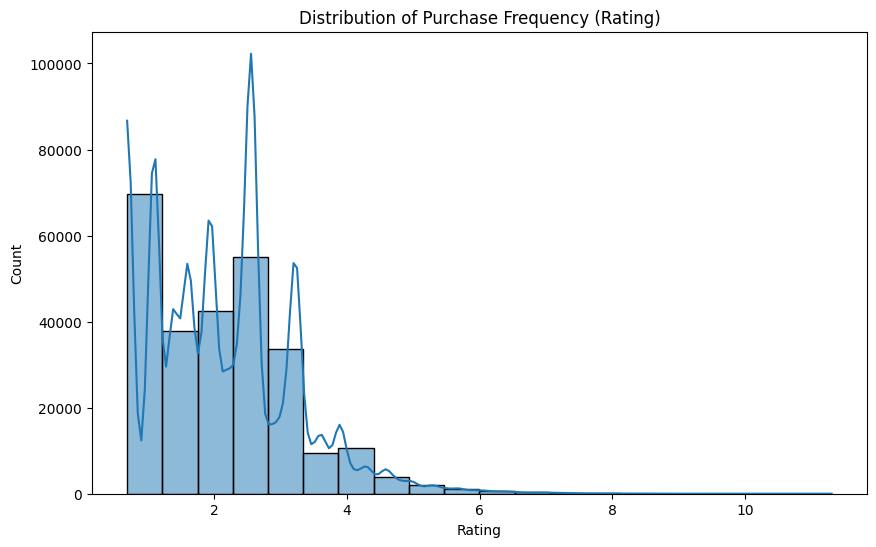


Data Sparsity: 98.32%
Unique Customers: 4338 | Unique Products: 3665
Total Interactions: 266792


In [ ]:
# Create user-product interaction with rating (based on quantity)
user_product = df.groupby(['CustomerID', 'StockCode']).agg({
    'Quantity': 'sum',
    'Description': 'first',
    'InvoiceDate': 'max'
}).reset_index()

user_product.rename(columns={'Quantity': 'rating'}, inplace=True)
user_product["rating"] = np.log1p(user_product["rating"])

# Rating Distribution
plt.figure(figsize=(10,6))
sns.histplot(user_product['rating'], bins=20, kde=True)
plt.title('Distribution of Purchase Frequency (Rating)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Sparsity Analysis
n_users = user_product['CustomerID'].nunique()
n_products = user_product['StockCode'].nunique()
sparsity = 1 - (len(user_product) / (n_users * n_products))
print(f"\nData Sparsity: {sparsity:.2%}")
print(f"Unique Customers: {n_users} | Unique Products: {n_products}")

print(f"Total Interactions: {len(user_product)}")



# 6. Model Building & Evaluation

The engineered interaction dataset was used to train and evaluate multiple collaborative filtering recommendation models.

### Data Preparation

The Surprise library was used to build recommendation models.

The interaction dataset was converted into the format required by Surprise and split into training and testing sets:

- Training Set: 80%
- Testing Set: 20%

The test set was used to evaluate the ability of each model to predict unseen customer-product interactions.

### Evaluation Metric

Model performance was evaluated using **Root Mean Squared Error (RMSE)**.

RMSE measures the difference between actual and predicted ratings.

- Lower RMSE indicates better prediction accuracy.
- A lower RMSE suggests that the recommendation model can more accurately estimate customer preferences.

### Models Evaluated

#### 1. Popularity-Based Baseline

A simple baseline approach was implemented by identifying products with the highest average ratings.

This provides a reference point against which collaborative filtering models can be compared.

#### 2. KNN Basic

KNN Basic is a neighborhood-based collaborative filtering algorithm.

Characteristics:

- Uses similarity between products.
- Recommends products based on patterns in customer interactions.
- Item-item similarity was calculated using cosine similarity.

#### 3. Singular Value Decomposition (SVD)

SVD is a matrix factorization technique widely used in recommendation systems.

Characteristics:

- Learns latent features representing customers and products.
- Handles sparse interaction matrices effectively.
- Often provides better recommendation quality than neighborhood-based methods.

### Hyperparameter Tuning

Grid Search Cross Validation was performed to identify the optimal SVD parameters.

The following parameters were tuned:

- Number of latent factors (`n_factors`)
- Number of training epochs (`n_epochs`)
- Learning rate (`lr_all`)

The parameter combination producing the lowest RMSE was selected for the final model.

### Objective

The objective of this phase is to compare different recommendation approaches and identify the model that provides the most accurate rating predictions for personalized product recommendations.

In [ ]:
reader = Reader(
    rating_scale=(
        user_product["rating"].min(),
        user_product["rating"].max()
    )
)
data = Dataset.load_from_df(user_product[['CustomerID', 'StockCode', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

# 1. Popularity Baseline
print("Popularity Baseline - Top Products:")
print(user_product.groupby('StockCode')['rating'].mean().nlargest(5))

# 2. KNN Basic
knn = KNNBasic(sim_options={'name': 'cosine', 'user_based': False})
knn.fit(trainset)
knn_preds = knn.test(testset)
print("\nKNN RMSE:", accuracy.rmse(knn_preds))

# 3. SVD with Hyperparameter Tuning
print("\nTuning SVD Model...")
param_grid = {'n_factors': [20, 50], 'n_epochs': [10, 20], 'lr_all': [0.005, 0.01]}
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
gs.fit(data)

print("Best RMSE:", gs.best_score['rmse'])
print("Best Parameters:", gs.best_params['rmse'])

# Train final best model
model = gs.best_estimator['rmse']
model.fit(trainset)
svd_preds = model.test(testset)
print("Final SVD RMSE:", accuracy.rmse(svd_preds))

Popularity Baseline - Top Products:
StockCode
23843     11.302155
47556B     7.863651
84568      6.068241
21897      5.998937
84598      5.448084
Name: rating, dtype: float64
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.8230

KNN RMSE: 0.8229998025177778

Tuning SVD Model...
Best RMSE: 0.6467898078611293
Best Parameters: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.01}
RMSE: 0.6340
Final SVD RMSE: 0.63400151885285


# 7. Recommendation Generation

After selecting the tuned SVD model, a recommendation function was developed to generate personalized product recommendations for individual customers.

### Recommendation Strategy

The recommendation process follows these steps:

1. Identify products already purchased by the customer.
2. Create a list of products that the customer has not purchased.
3. Use the trained SVD model to predict the customer's rating for each unseen product.
4. Rank products based on predicted ratings.
5. Return the top-N highest ranked products as recommendations.

### Personalization

Recommendations are generated using collaborative filtering. The model learns hidden patterns from customer-product interactions and predicts products that a customer is likely to prefer based on historical purchasing behavior.

### Output

For each recommendation, the system returns:

- Product Code
- Product Description
- Predicted Preference Score

Higher predicted scores indicate a stronger likelihood that the customer will be interested in the product.

In [ ]:
def get_top_n_recommendations(customer_id, n=5):

    products = user_product[['StockCode', 'Description']].drop_duplicates()

    # Get products already bought by customer
    bought = set(user_product[user_product['CustomerID'] == customer_id]['StockCode'].values)

    # Get candidates (all products not bought)
    candidates = products[~products['StockCode'].isin(bought)]

    # Get predictions for a reasonable number of candidates
    predictions = []
    for _, row in candidates.iterrows():
        pred = model.predict(customer_id, row['StockCode'])
        predictions.append((row['StockCode'], row['Description'], pred.est))

    # Sort and return top N
    predictions.sort(key=lambda x: x[2], reverse=True)
    return predictions[:n]

# Test it
print("Testing Optimized Recommendation:")

sample_customer = user_product['CustomerID'].sample(
    1, random_state=42
).iloc[0]
recs = get_top_n_recommendations(sample_customer, 5)

for _, desc, score in recs:
    print(f"• {desc} (Predicted Score: {score:.2f})")

Testing Optimized Recommendation:
• GIRLS ALPHABET IRON ON PATCHES  (Predicted Score: 5.76)
• POPART WOODEN PENCILS ASST (Predicted Score: 4.87)
• ASSORTED INCENSE PACK (Predicted Score: 4.77)
• PIECE OF CAMO STATIONERY SET (Predicted Score: 4.57)
• DISCO BALL CHRISTMAS DECORATION (Predicted Score: 4.24)


# 8. Interactive Demo

A simple Gradio interface allows users to enter a Customer ID and receive personalized product recommendations generated by the trained SVD model.

In [ ]:
import gradio as gr

def recommend_for_customer(customer_id, top_n=5):
    try:

        customer_id = int(customer_id)

        #Check if the customer exists
        if customer_id not in user_product["CustomerID"].unique():
            return (
                f"Customer ID {customer_id} does not exist in the dataset.\n"
                "Please enter a valid Customer ID (e.g., 13047)."
            )
        recs = get_top_n_recommendations(int(customer_id), int(top_n))
        output = "\n".join([f"• {desc} (Predicted Preference: {score:.2f})" for _, desc, score in recs])
        return output
    except Exception as e:
        return f"Error: Customer ID not found or invalid. Try another ID (e.g., 17850)"

demo = gr.Interface(
    fn=recommend_for_customer,
    inputs=[
        gr.Textbox(label="Enter Customer ID", placeholder="13047"),
        gr.Slider(1, 10, value=5, label="Number of Recommendations")
    ],
    outputs=gr.Textbox(label="Recommended Products", lines = 10),
    title="E-commerce Product Recommendation System",
    description="SVD-based Collaborative Filtering Recommender"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d81c915cb1651b752.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 9. Conclusion

This project demonstrates how collaborative filtering can be used to generate personalized product recommendations from transactional data. After comparing multiple approaches, the tuned SVD model provided the best performance and was deployed through an interactive Gradio interface.